In [25]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/abbas829/e-commerce-sales-analytics-dataset/ecommerce_sales_analytics_5000.csv


In [26]:
data=pd.read_csv('/kaggle/input/datasets/abbas829/e-commerce-sales-analytics-dataset/ecommerce_sales_analytics_5000.csv')

In [27]:
data.head()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,1/1/2022,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,10002,1/2/2022,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
2,10003,1/3/2022,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35
3,10004,1/4/2022,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90
4,10005,1/5/2022,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56


In [28]:
data.shape

(5000, 12)

In [29]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5000 non-null   int64  
 1   order_date        5000 non-null   object 
 2   customer_id       5000 non-null   int64  
 3   product_category  5000 non-null   object 
 4   region            5000 non-null   object 
 5   quantity          5000 non-null   int64  
 6   unit_price        5000 non-null   float64
 7   discount          5000 non-null   float64
 8   payment_method    5000 non-null   object 
 9   delivery_days     5000 non-null   int64  
 10  customer_rating   5000 non-null   float64
 11  revenue           5000 non-null   float64
dtypes: float64(4), int64(4), object(4)
memory usage: 468.9+ KB


In [30]:
data.isnull().sum()

order_id            0
order_date          0
customer_id         0
product_category    0
region              0
quantity            0
unit_price          0
discount            0
payment_method      0
delivery_days       0
customer_rating     0
revenue             0
dtype: int64

In [31]:
data.duplicated().sum()

np.int64(0)

In [32]:
data.dtypes

order_id              int64
order_date           object
customer_id           int64
product_category     object
region               object
quantity              int64
unit_price          float64
discount            float64
payment_method       object
delivery_days         int64
customer_rating     float64
revenue             float64
dtype: object

In [33]:
data.columns

Index(['order_id', 'order_date', 'customer_id', 'product_category', 'region',
       'quantity', 'unit_price', 'discount', 'payment_method', 'delivery_days',
       'customer_rating', 'revenue'],
      dtype='object')

In [34]:
data.drop(['order_id', 'order_date', 'customer_id'], axis=1, inplace=True)

In [35]:
data.head()

,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
2,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35
3,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90
4,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56


In [37]:
data.shape


(5000, 9)

In [38]:
data.head()

,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
2,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35
3,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90
4,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56


In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

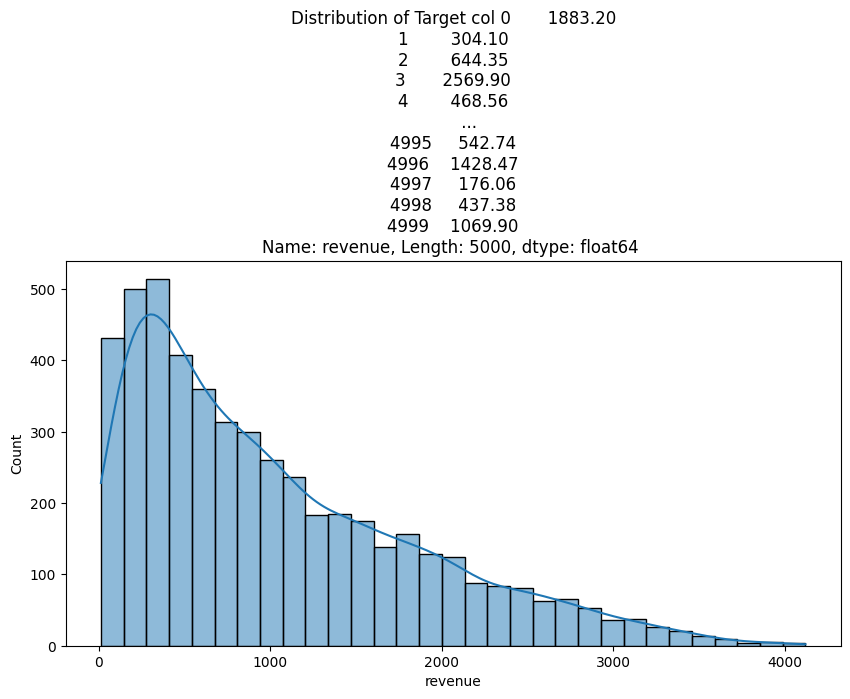

In [52]:
plt.figure(figsize=(10,5));
sns.histplot(data['revenue'], kde=True);
plt.title(f"Distribution of Target col {data['revenue']} ");
plt.show();

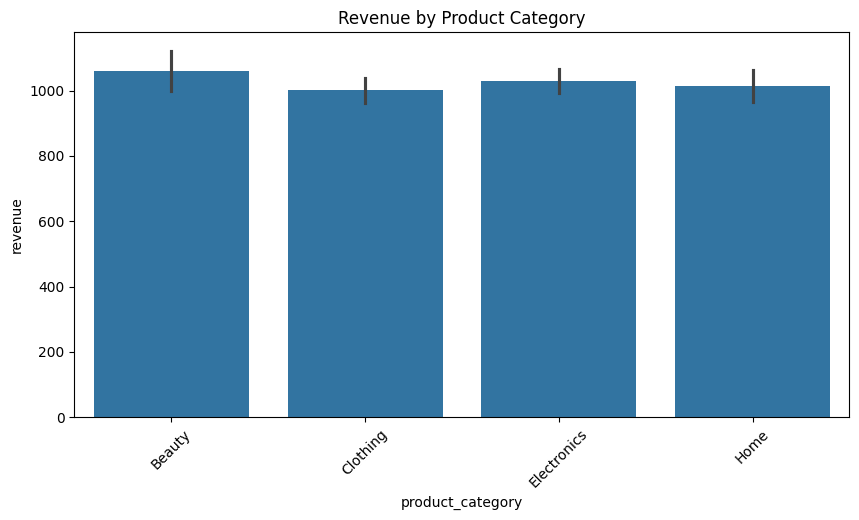

In [53]:
plt.figure(figsize=(10,5))
sns.barplot(x='product_category', y='revenue', data=data)
plt.xticks(rotation=45)
plt.title("Revenue by Product Category")
plt.show()

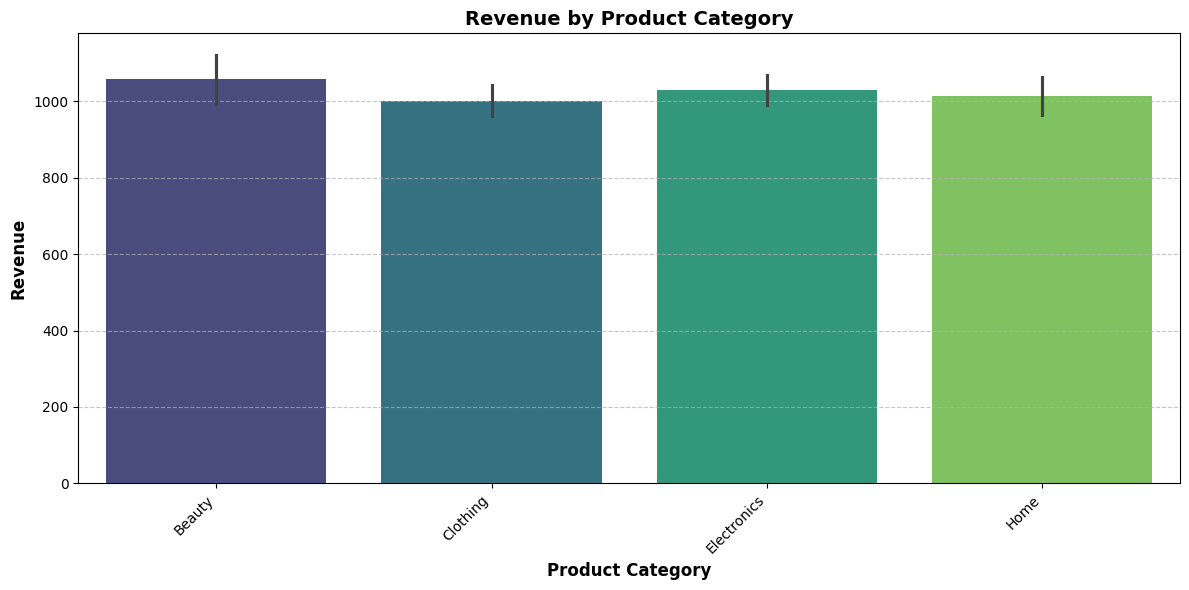

In [54]:
plt.figure(figsize=(12,6))  # Figure ka size thora bada for better visibility

# Barplot with better styling
sns.barplot(
    x='product_category', 
    y='revenue', 
    data=data,
    palette='viridis'   # Color theme
)

# X-axis labels rotate karna (agar categories zyada hoon)
plt.xticks(rotation=45, ha='right', fontsize=10)

# Labels add karna
plt.xlabel("Product Category", fontsize=12, fontweight='bold')
plt.ylabel("Revenue", fontsize=12, fontweight='bold')

# Title ko attractive banana
plt.title("Revenue by Product Category", fontsize=14, fontweight='bold')

# Grid add karna for readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Layout adjust (cutting avoid karne ke liye)
plt.tight_layout()

# Final output
plt.show()

In [55]:
corr = data.corr(numeric_only=True)
print(corr)

                 quantity  unit_price  discount  delivery_days  \
quantity         1.000000    0.001498 -0.004302      -0.008748   
unit_price       0.001498    1.000000  0.013215       0.015623   
discount        -0.004302    0.013215  1.000000      -0.000382   
delivery_days   -0.008748    0.015623 -0.000382       1.000000   
customer_rating  0.019168    0.005025  0.012776      -0.017625   
revenue          0.623564    0.678032 -0.139296       0.005444   

                 customer_rating   revenue  
quantity                0.019168  0.623564  
unit_price              0.005025  0.678032  
discount                0.012776 -0.139296  
delivery_days          -0.017625  0.005444  
customer_rating         1.000000  0.012446  
revenue                 0.012446  1.000000  


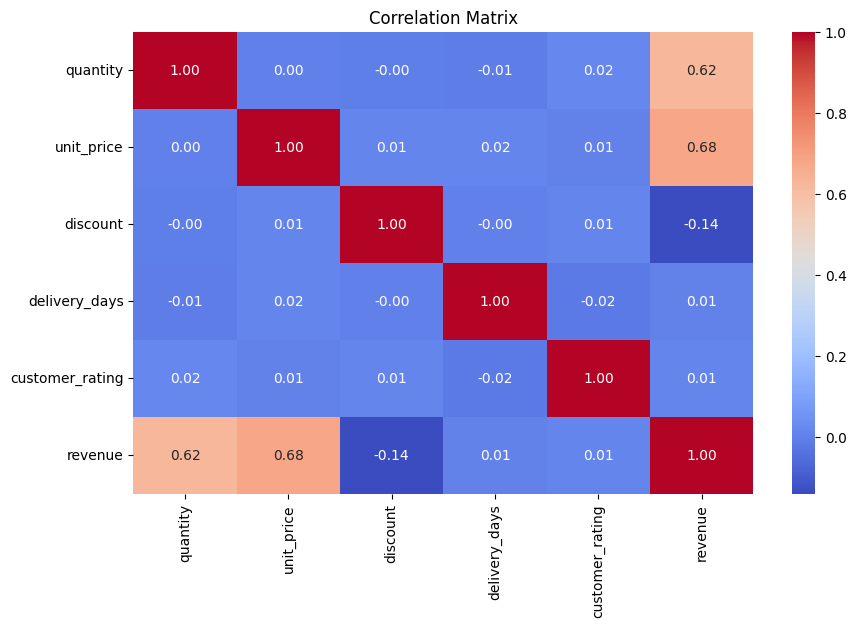

In [57]:
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

<Axes: xlabel='product_category', ylabel='revenue'>

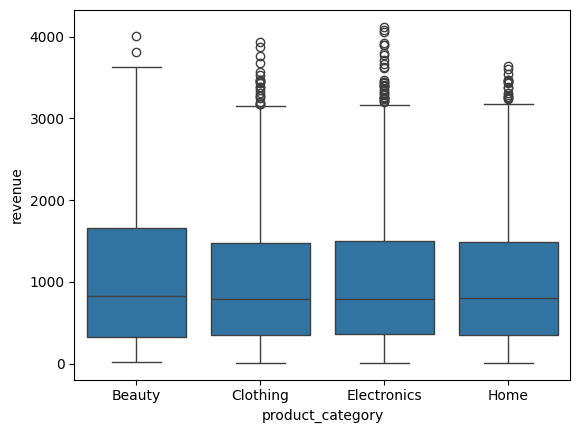

In [58]:
sns.boxplot(x='product_category', y='revenue', data=data)

In [59]:
X = data[['quantity', 'unit_price', 'discount', 'delivery_days', 'customer_rating']]
y = data['revenue']

In [61]:
print(y)

0       1883.20
1        304.10
2        644.35
3       2569.90
4        468.56
         ...   
4995     542.74
4996    1428.47
4997     176.06
4998     437.38
4999    1069.90
Name: revenue, Length: 5000, dtype: float64


In [62]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [65]:
X_train.shape,X_test.shape

((4000, 5), (1000, 5))

In [66]:
y_train.shape,y_test.shape

((4000,), (1000,))

In [74]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [75]:
X_train

array([[ 1.46632408,  1.20462513,  1.56212779, -0.99149115,  1.49414441],
       [-0.51085317, -1.17336265, -0.9874044 ,  1.54550844, -1.28138289],
       [-0.01655886,  0.99037661, -1.67381691,  1.54550844,  0.62679213],
       ...,
       [-1.00514748, -0.41180603, -1.28158119,  0.59413359, -0.6742363 ],
       [ 0.97202977, -0.02787787, -0.79128654,  1.22838349,  0.88699781],
       [ 1.46632408,  0.23853447,  0.87571528, -0.04011631, -1.28138289]])

In [77]:
from sklearn.preprocessing import PolynomialFeatures

In [78]:
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [84]:
from sklearn.linear_model import LinearRegression

In [85]:
model = LinearRegression()
model.fit(X_train_poly, y_train)


LinearRegression()

In [86]:
y_pred = model.predict(X_test_poly)

In [87]:
from sklearn.metrics import r2_score

In [88]:
accuracy = r2_score(y_test, y_pred)
print("Polynomial Model Accuracy (R2 Score):", accuracy)

Polynomial Model Accuracy (R2 Score): 0.9984021988288125


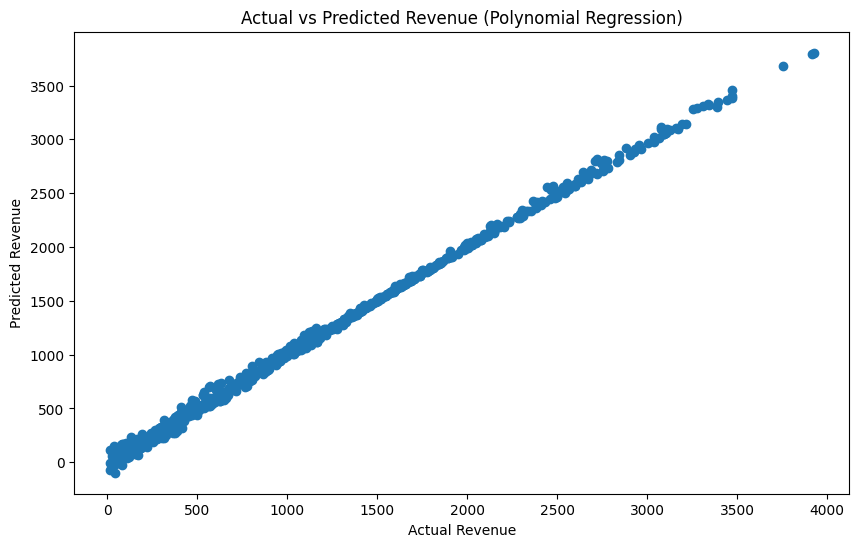

In [89]:
fig = plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")
plt.title("Actual vs Predicted Revenue (Polynomial Regression)")
plt.show()

In [90]:
from sklearn.metrics import r2_score

y_train_pred = model.predict(X_train_poly)
y_test_pred = model.predict(X_test_poly)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Train R2:", train_r2)
print("Test R2:", test_r2)

Train R2: 0.9981804577747775
Test R2: 0.9984021988288125


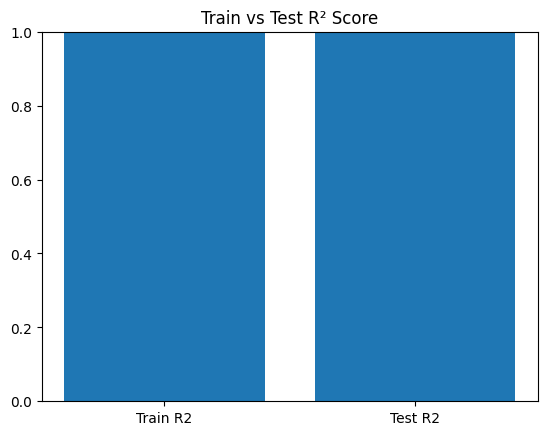

In [91]:
import matplotlib.pyplot as plt

labels = ['Train R2', 'Test R2']
scores = [train_r2, test_r2]

plt.bar(labels, scores)
plt.ylim(0, 1)
plt.title("Train vs Test R² Score")
plt.show()

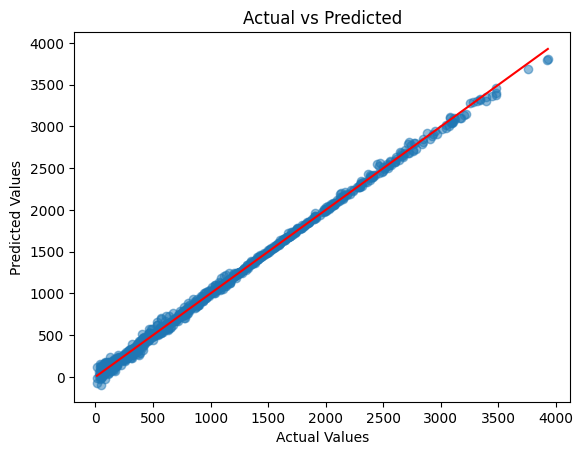

In [92]:
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')  # perfect prediction line
plt.show()

In [93]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_test_pred)
print("MAE:", mae)

#this means if value is 500 model will pridict either 479 or 521

MAE: 21.437088818530174
